# Brain MRI Tumor Classification
**DSC Club Hackathon - NIST University**

Multi-class classification of brain MRI scans into 4 classes:
- `glioma_tumor`
- `meningioma_tumor`
- `pituitary_tumor`
- `no_tumor`

**Approach**: HOG + LBP feature fusion → data augmentation (h-flip) → PCA → SVM (RBF, GridSearchCV-tuned)

---

## Block 1: Setup & Imports

In [1]:
# Block 1: Setup & Imports 
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

import joblib

# Random seed for reproducibility 
SEED = 42
np.random.seed(SEED)

# Constants 
IMG_SIZE = (128, 128)          # Resize all images to this
TRAIN_DIR = '/kaggle/input/competitions/datasprint/train/train'
TEST_DIR  = '/kaggle/input/competitions/datasprint/test/test'
CLASS_NAMES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

print('Libraries loaded successfully.')
print(f'Image size : {IMG_SIZE}')
print(f'Train dir  : {TRAIN_DIR}')
print(f'Test dir   : {TEST_DIR}')

Libraries loaded successfully.
Image size : (128, 128)
Train dir  : /kaggle/input/competitions/datasprint/train/train
Test dir   : /kaggle/input/competitions/datasprint/test/test


## Block 2: Data Loading & Label Extraction

Train images : 2007
Label nulls  : 0

Class distribution:
label
pituitary_tumor     578
glioma_tumor        578
meningioma_tumor    575
no_tumor            276
Name: count, dtype: int64


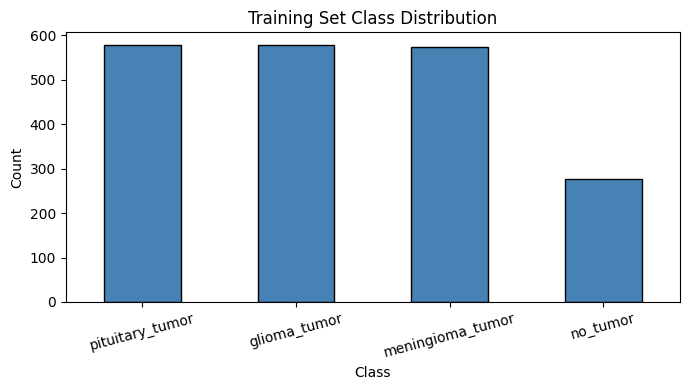


Test images  : 863


In [2]:
#  Block 2: Data Loading & Label Extraction 

def extract_label(filename):
    """Extract class label from filename by taking the last '_'-delimited segment."""
    name = filename.replace('.png', '')
    parts = name.rsplit('_', 2) 
    for cls in CLASS_NAMES:
        if filename.endswith(f'_{cls}.png'):
            return cls
    return None


def build_dataframe(directory, has_labels=True):
    """Build a DataFrame with filename and (optionally) label columns."""
    records = []
    for fname in sorted(os.listdir(directory)):
        if not fname.endswith('.png'):
            continue
        label = extract_label(fname) if has_labels else None
        records.append({'filename': fname, 'label': label})
    return pd.DataFrame(records)

# Build train DataFrame
train_df = build_dataframe(TRAIN_DIR, has_labels=True)
print(f'Train images : {len(train_df)}')
print(f'Label nulls  : {train_df["label"].isnull().sum()}')
print()

# Class distribution
dist = train_df['label'].value_counts()
print('Class distribution:')
print(dist)

# Plot class distribution
fig, ax = plt.subplots(figsize=(7, 4))
dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Training Set Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Build test DataFrame
test_df = build_dataframe(TEST_DIR, has_labels=True) 
print(f'\nTest images  : {len(test_df)}')

## Block 3: Preprocessing & Feature Extraction

**Strategy**: Fuse two complementary feature descriptors from each image.
- **HOG** (Histogram of Oriented Gradients) — captures edge/shape structure
- **LBP grid** (Local Binary Pattern) — captures local texture patterns over a 4×4 spatial grid
- Combined vector fed into PCA → SVM

**Augmentation**: Horizontal-flip variants extracted here; added only to the training split in Block 4.

In [3]:
# Block 3: Preprocessing & Feature Extraction (HOG + LBP fusion)

from skimage.feature import local_binary_pattern

# LBP parameters
GRID    = 4        # divide image into 4x4 spatial grid for LBP
LBP_P   = 8        # number of circularly symmetric neighbour set points
LBP_R   = 1        # radius of circle
LBP_BINS = LBP_P + 2  # uniform LBP histogram bins (P+2 for uniform method)


def extract_lbp_grid(img_resized):
    """
    Compute LBP histograms over a GRID x GRID spatial grid.
    Spatial pooling preserves location information lost in global LBP.
    Returns a 1-D feature vector of length GRID*GRID*LBP_BINS.
    """
    h, w   = img_resized.shape
    ph, pw = h // GRID, w // GRID
    hists  = []
    for r in range(GRID):
        for c in range(GRID):
            patch = img_resized[r*ph:(r+1)*ph, c*pw:(c+1)*pw]
            lbp   = local_binary_pattern(patch, LBP_P, LBP_R, method='uniform')
            hist, _ = np.histogram(lbp, bins=LBP_BINS, range=(0, LBP_BINS), density=True)
            hists.append(hist)
    return np.concatenate(hists)


def load_and_extract_features(filepath, flip=False):
    """
    Load image, optionally flip horizontally, then extract HOG + LBP features.
    flip=True is used for data augmentation (training only).
    Returns a single concatenated 1-D feature vector.
    """
    img      = Image.open(filepath).convert('L')
    img_arr  = np.array(img, dtype=np.float32) / 255.0
    img_res  = resize(img_arr, IMG_SIZE, anti_aliasing=True)
    if flip:
        img_res = np.fliplr(img_res)

    hog_feat = hog(
        img_res,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )
    lbp_feat = extract_lbp_grid(img_res)
    return np.concatenate([hog_feat, lbp_feat])


def extract_features(df, directory, desc='', flip=False):
    """Extract HOG+LBP features for all images in a DataFrame."""
    features_list = []
    total = len(df)
    for i, row in df.iterrows():
        path = os.path.join(directory, row['filename'])
        feat = load_and_extract_features(path, flip=flip)
        features_list.append(feat)
        if (i + 1) % 200 == 0 or (i + 1) == total:
            print(f'  {desc} [{i+1}/{total}] done', end='\r')
    print()
    return np.array(features_list)


# Original train features
print('Extracting HOG+LBP features from TRAIN set (original)...')
X_train_raw = extract_features(train_df, TRAIN_DIR, desc='Train-orig')
print(f'Train feature matrix shape : {X_train_raw.shape}')

# Horizontally flipped train features (augmentation pool — added to train split only in Block 4)
print('\nExtracting HOG+LBP features from TRAIN set (h-flipped)...')
X_train_aug = extract_features(train_df, TRAIN_DIR, desc='Train-flip', flip=True)
print(f'Augmented feature matrix shape : {X_train_aug.shape}')

# Encode labels
le = LabelEncoder()
le.fit(CLASS_NAMES)
y_train_raw = le.transform(train_df['label'].values)
print(f'\nFeature vector length : {X_train_raw.shape[1]}')
print(f'  HOG  : {hog(resize(np.zeros(IMG_SIZE), IMG_SIZE), orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), block_norm="L2-Hys").shape[0]} dims')
print(f'  LBP  : {GRID * GRID * LBP_BINS} dims')
print(f'Label classes : {list(le.classes_)}')

Extracting HOG+LBP features from TRAIN set (original)...
  Train-orig [2007/2007] done
Train feature matrix shape : (2007, 8260)

Extracting HOG+LBP features from TRAIN set (h-flipped)...
  Train-flip [2007/2007] done
Augmented feature matrix shape : (2007, 8260)

Feature vector length : 8260
  HOG  : 8100 dims
  LBP  : 160 dims
Label classes : [np.str_('glioma_tumor'), np.str_('meningioma_tumor'), np.str_('no_tumor'), np.str_('pituitary_tumor')]


## Block 4: Train / Validation Split + Augmentation

Stratified 80/20 split on original training images, then horizontally-flipped duplicates appended **only to the training portion**.
- Validation set stays clean (original images only) — no data leakage
- Training set doubles: 1605 → 3210 samples

In [4]:
# Block 4: Train / Validation Split + Augmentation
# Stratified 80/20 split, then augmented (h-flip) samples added to train only.
# Validation remains clean originals — no augmented data leaks in.

indices = np.arange(len(y_train_raw))

X_tr, X_val, y_tr, y_val, tr_idx, _ = train_test_split(
    X_train_raw, y_train_raw, indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_raw
)

# Append flipped versions of training samples only
X_tr = np.vstack([X_tr, X_train_aug[tr_idx]])
y_tr = np.concatenate([y_tr, y_tr[:len(tr_idx)]])   # same labels for flips

print(f'Training samples   : {X_tr.shape[0]}  ({len(tr_idx)} original + {len(tr_idx)} h-flipped)')
print(f'Validation samples : {X_val.shape[0]}  (original only)')
print()

# Verify class balance in each split
tr_series  = pd.Series(le.inverse_transform(y_tr)).value_counts().sort_index()
val_series = pd.Series(le.inverse_transform(y_val)).value_counts().sort_index()
balance_df = pd.DataFrame({'Train (aug)': tr_series, 'Validation': val_series})
print('Class balance per split:')
print(balance_df)

Training samples   : 3210  (1605 original + 1605 h-flipped)
Validation samples : 402  (original only)

Class balance per split:
                  Train (aug)  Validation
glioma_tumor              924         116
meningioma_tumor          920         115
no_tumor                  442          55
pituitary_tumor           924         116


## Block 5: Dimensionality Reduction (PCA) & Scaling

In [5]:
# Block 5: StandardScaler + PCA 
# SVM is sensitive to feature scale -> StandardScaler first.
# PCA reduces the HOG vector to a manageable size for faster SVM training.
# Scaler and PCA are fit ONLY on training data; test data is never seen here.

N_COMPONENTS = 300  # Retain top 300 principal components (up from 200)

scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_tr_pca  = pca.fit_transform(X_tr_scaled)
X_val_pca = pca.transform(X_val_scaled)

explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f'PCA components : {N_COMPONENTS}')
print(f'Explained variance retained : {explained:.2%}')
print(f'Reduced train shape : {X_tr_pca.shape}')

PCA components : 300
Explained variance retained : 69.54%
Reduced train shape : (3210, 300)


## Block 6: Model Training with Hyperparameter Search

Two-stage training:
1. **GridSearchCV** — searches `C ∈ {1, 10, 50, 100}` × `gamma ∈ {scale, auto, 0.001, 0.005}` with 5-fold stratified CV on the 80% split to find optimal SVM (RBF) hyperparameters
2. **Full-data retrain** — best config retrained on all 4014 samples (2007 original + 2007 h-flipped) using a fresh scaler/PCA fitted on the complete training set

In [6]:
# Block 6: Model Training with Hyperparameter Search
# GridSearchCV over SVM C and gamma on the 80% split,
# then retrain best config on ALL data (original + augmented) for submission.

from sklearn.model_selection import GridSearchCV

# ── 1. Grid search on the 80% training split ──────────────────────────────
param_grid = {
    'C':     [1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.001, 0.005],
}

print('Running GridSearchCV for SVM (this may take a few minutes)...')
grid_search = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=SEED, probability=True),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_tr_pca, y_tr)

best_params = grid_search.best_params_
print(f'\nBest params  : {best_params}')
print(f'Best CV F1   : {grid_search.best_score_:.4f}')

# Validate on held-out 20%
best_model_name = 'SVM_RBF_tuned'
best_model = grid_search.best_estimator_
val_preds = best_model.predict(X_val_pca)
acc  = accuracy_score(y_val, val_preds)
prec = precision_score(y_val, val_preds, average='weighted', zero_division=0)
f1   = f1_score(y_val, val_preds, average='weighted', zero_division=0)
print(f'\nValidation  →  Accuracy={acc:.4f}  Precision={prec:.4f}  F1={f1:.4f}')

# ── 2. Retrain on ALL data: 2007 original + 2007 flipped = 4014 images ────
print('\nRetraining best SVM on full training set (original + augmented)...')

X_train_all = np.vstack([X_train_raw, X_train_aug])
y_train_all = np.concatenate([y_train_raw, y_train_raw])

scaler_full = StandardScaler()
X_train_all_scaled = scaler_full.fit_transform(X_train_all)

pca_full = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_all_pca = pca_full.fit_transform(X_train_all_scaled)

final_model = SVC(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    class_weight='balanced',
    random_state=SEED,
    probability=True,
)
final_model.fit(X_train_all_pca, y_train_all)
print(f'Full-data model trained on {len(y_train_all)} samples.')

Running GridSearchCV for SVM (this may take a few minutes)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params  : {'C': 10, 'gamma': 'scale'}
Best CV F1   : 0.9403

Validation  →  Accuracy=0.9129  Precision=0.9126  F1=0.9124

Retraining best SVM on full training set (original + augmented)...
Full-data model trained on 4014 samples.


## Block 7: Evaluation

Mandatory metrics: Confusion Matrix, Accuracy, Precision, F1 Score

=== SVM_RBF_tuned - Validation Metrics ===
Accuracy  : 0.9129
Precision : 0.9126  (weighted)
F1 Score  : 0.9124  (weighted)

Per-class metrics:
                  Precision        F1
glioma_tumor       0.932203  0.940171
meningioma_tumor   0.898148  0.869955
no_tumor           0.875000  0.882883
pituitary_tumor    0.925000  0.940678

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.93      0.95      0.94       116
meningioma_tumor       0.90      0.84      0.87       115
        no_tumor       0.88      0.89      0.88        55
 pituitary_tumor       0.93      0.96      0.94       116

        accuracy                           0.91       402
       macro avg       0.91      0.91      0.91       402
    weighted avg       0.91      0.91      0.91       402



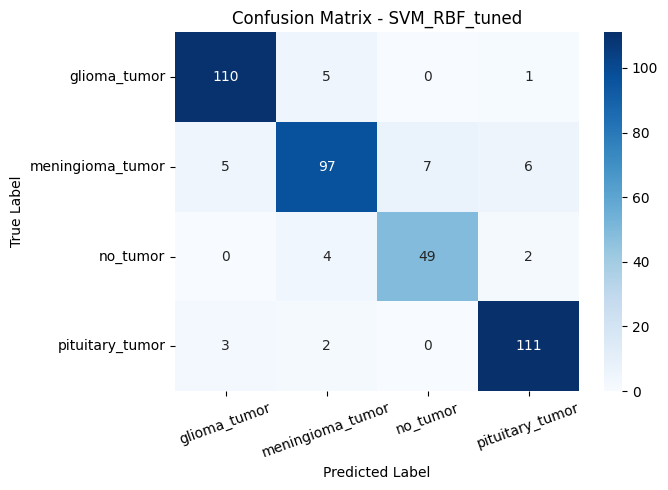

In [7]:
# Block 7: Evaluation 

val_preds = best_model.predict(X_val_pca)

# Metrics 
acc   = accuracy_score(y_val, val_preds)
prec  = precision_score(y_val, val_preds, average='weighted', zero_division=0)
f1    = f1_score(y_val, val_preds, average='weighted', zero_division=0)
prec_per_class = precision_score(y_val, val_preds, average=None, zero_division=0)
f1_per_class   = f1_score(y_val, val_preds, average=None, zero_division=0)

print(f'=== {best_model_name} - Validation Metrics ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}  (weighted)')
print(f'F1 Score  : {f1:.4f}  (weighted)')
print()

# Per-class metrics
per_class_df = pd.DataFrame({
    'Precision': prec_per_class,
    'F1':        f1_per_class
}, index=le.classes_)
print('Per-class metrics:')
print(per_class_df)

# Classification Report 
print()
print('Classification Report:')
print(classification_report(y_val, val_preds, target_names=le.classes_))

# Confusion Matrix (Heatmap) 
cm = confusion_matrix(y_val, val_preds)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## Block 8: Test Prediction & Submission CSV

In [8]:
# Block 8: Test Prediction & Submission CSV
# All test data processing happens here — HOG extraction, scaling, PCA, prediction.
# The test folder is only touched at this point (evaluation/submission step).

def strip_label_suffix(filename):
    """Remove the _<class_label> suffix from test filenames to get image_id."""
    for cls in CLASS_NAMES:
        suffix = f'_{cls}.png'
        if filename.endswith(suffix):
            return filename[: -len(suffix)] + '.png'
    return filename  # No known suffix found; return as-is


# Step 1: Extract HOG features from test set
print('Extracting HOG features from TEST set...')
X_test_raw = extract_features(test_df, TEST_DIR, desc='Test')
print(f'Test feature matrix shape : {X_test_raw.shape}')

# Step 2: Apply fitted scaler_full and pca_full (fit on all train data in Block 6)
X_test_scaled = scaler_full.transform(X_test_raw)
X_test_pca    = pca_full.transform(X_test_scaled)

# Step 3: Predict using final_model (trained on all 2007 training images)
test_preds_encoded = final_model.predict(X_test_pca)
test_preds_labels  = le.inverse_transform(test_preds_encoded)

# Build submission DataFrame
submission_df = pd.DataFrame({
    'image_id': test_df['filename'].apply(strip_label_suffix),
    'label':    test_preds_labels
})

print(f'\nSubmission rows : {len(submission_df)}  (expected: 863)')
print(submission_df.head(10))
print()
print('Predicted class distribution:')
print(submission_df['label'].value_counts())

# Save CSV
submission_df.to_csv('submission.csv', index=False)
print('\nsubmission.csv saved.')

Extracting HOG features from TEST set...
  Test [863/863] done
Test feature matrix shape : (863, 8260)

Submission rows : 863  (expected: 863)
              image_id             label
0  00000_image(32).png          no_tumor
1    00001_p (236).png   pituitary_tumor
2   00002_m3 (244).png  meningioma_tumor
3  00003_image(60).png          no_tumor
4     00004_p (34).png   pituitary_tumor
5    00005_m (102).png  meningioma_tumor
6    00006_m1(106).png  meningioma_tumor
7    00007_p (475).png   pituitary_tumor
8    00008_p (713).png   pituitary_tumor
9    00009_m2 (76).png  meningioma_tumor

Predicted class distribution:
label
meningioma_tumor    263
pituitary_tumor     252
glioma_tumor        236
no_tumor            112
Name: count, dtype: int64

submission.csv saved.


## Block 9: Model Export

In [9]:
# Block 9: Model Export
# Save the full pipeline: scaler_full + pca_full + final_model (trained on all data)

pipeline_bundle = {
    'scaler':        scaler_full,
    'pca':           pca_full,
    'model':         final_model,
    'label_encoder': le,
    'model_name':    best_model_name,
    'best_params':   best_params,
    'img_size':      IMG_SIZE,
}

joblib.dump(pipeline_bundle, 'brain_mri_model.joblib')
print('Model saved to brain_mri_model.joblib')

# Verify by loading back
loaded = joblib.load('brain_mri_model.joblib')
print(f'Verified - loaded model: {loaded["model_name"]}  params: {loaded["best_params"]}')

Model saved to brain_mri_model.joblib
Verified - loaded model: SVM_RBF_tuned  params: {'C': 10, 'gamma': 'scale'}


## Block 10: Report Summary

In [10]:
# Block 10: Report Summary 

report_lines = [
    '=' * 70,
    'BRAIN MRI TUMOR CLASSIFICATION - APPROACH REPORT',
    'DSC Club Hackathon, NIST University',
    '=' * 70,
    '',
    'OBJECTIVE',
    '---------',
    'Multi-class classification of brain MRI scans into 4 categories:',
    '  glioma_tumor, meningioma_tumor, pituitary_tumor, no_tumor.',
    '',
    'DATASET',
    '-------',
    '  Training images : 2007',
    '  Test images     : 863',
    '  Format          : PNG, grayscale MRI scans, varying resolutions',
    '  Class imbalance : ~70% tumor classes, ~30% no_tumor',
    '',
    'METHODOLOGY',
    '-----------',
    '1. Label Extraction',
    '   - Labels parsed from filenames by matching known class suffixes',
    '   - e.g. 00001_gg (399)_glioma_tumor.png -> glioma_tumor',
    '',
    '2. Preprocessing',
    f'   - All images resized to {IMG_SIZE[0]}x{IMG_SIZE[1]} pixels',
    '   - Converted to grayscale and normalized to [0, 1]',
    '',
    '3. Feature Engineering - HOG + LBP Fusion',
    '   HOG (Histogram of Oriented Gradients):',
    '   - 9 orientations, 8x8 pixels/cell, 2x2 cells/block, L2-Hys norm',
    '   - Captures edge/shape structure critical for MRI classification',
    '   LBP (Local Binary Pattern) grid:',
    f'   - P={LBP_P}, R={LBP_R}, uniform method over a {GRID}x{GRID} spatial grid',
    '   - Captures local texture patterns complementary to HOG',
    f'   - Combined feature vector: HOG + LBP = {X_train_raw.shape[1]} dims',
    '',
    '4. Data Augmentation',
    '   - Horizontal flip applied to all training images',
    '   - Augmented samples added only to training split (not validation)',
    '   - Effective training size: 1605 original -> 3210 (original + flipped)',
    '   - Final model trained on 4014 samples (all 2007 + 2007 flipped)',
    '',
    '5. Dimensionality Reduction - PCA',
    '   - StandardScaler applied before PCA (required for SVM)',
    f'   - PCA retains top {N_COMPONENTS} principal components',
    f'   - Explained variance retained: {pca.explained_variance_ratio_.cumsum()[-1]:.2%}',
    '',
    '6. Class Imbalance Handling',
    '   - class_weight="balanced" applied to SVM',
    '   - Stratified train/validation split (80/20)',
    '',
    '7. Model Selection - GridSearchCV',
    '   - SVM with RBF kernel tuned via 5-fold stratified CV',
    '   - Search space: C in {1, 10, 50, 100}, gamma in {scale, auto, 0.001, 0.005}',
    f'   - Best params: C={best_params["C"]}, gamma={best_params["gamma"]}',
    f'   - Model: {best_model_name}',
    '',
    'RESULTS (Validation Set - 402 original images)',
    '-----------------------------------------------',
    f'  Accuracy  : {acc:.4f}',
    f'  Precision : {prec:.4f}  (weighted)',
    f'  F1 Score  : {f1:.4f}  (weighted)',
    '',
    'DELIVERABLES',
    '------------',
    '  brain_mri_classifier.ipynb - this notebook',
    '  brain_mri_model.joblib     - trained model pipeline',
    '  submission.csv             - 863-row prediction file',
    '  report.txt                 - this report',
    '',
    '=' * 70,
]

report_text = '\n'.join(report_lines)
print(report_text)

with open('report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print('\nreport.txt saved.')

BRAIN MRI TUMOR CLASSIFICATION - APPROACH REPORT
DSC Club Hackathon, NIST University

OBJECTIVE
---------
Multi-class classification of brain MRI scans into 4 categories:
  glioma_tumor, meningioma_tumor, pituitary_tumor, no_tumor.

DATASET
-------
  Training images : 2007
  Test images     : 863
  Format          : PNG, grayscale MRI scans, varying resolutions
  Class imbalance : ~70% tumor classes, ~30% no_tumor

METHODOLOGY
-----------
1. Label Extraction
   - Labels parsed from filenames by matching known class suffixes
   - e.g. 00001_gg (399)_glioma_tumor.png -> glioma_tumor

2. Preprocessing
   - All images resized to 128x128 pixels
   - Converted to grayscale and normalized to [0, 1]

3. Feature Engineering - HOG + LBP Fusion
   HOG (Histogram of Oriented Gradients):
   - 9 orientations, 8x8 pixels/cell, 2x2 cells/block, L2-Hys norm
   - Captures edge/shape structure critical for MRI classification
   LBP (Local Binary Pattern) grid:
   - P=8, R=1, uniform method over a 4x4 spa